# 🤖 Laboratorio 2 — Fundamentos de Aprendizaje Automático
**Bootcamp IA Intermedio | Talento Tech Valle**

## Objetivos
1. Limpiar y preparar datos reales con pandas
2. Aplicar Feature Engineering para crear variables más informativas
3. Evaluar modelos con validación cruzada
4. Entrenar y comparar KNN, Regresión Logística, Árbol de Decisión y Random Forest
5. Calcular Matriz de Confusión, Precisión, Recall, F1, ROC y AUC
6. Aplicar K-Means clustering y PCA

**Stack:** Python · pandas · numpy · scikit-learn · matplotlib · seaborn

In [1]:
# ── Imports globales ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             mean_squared_error, r2_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.impute import KNNImputer

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


---
## 1. 🧹 Preparación y Limpieza de Datos
**Dataset:** Titanic (seaborn)  
**Concepto clave:** Antes de entrenar cualquier modelo, los datos deben estar limpios.
Un modelo entrenado con datos sucios aprende patrones equivocados — basura entra, basura sale.

### Pipeline de limpieza:
1. Detectar nulos → `isnull().sum()`
2. Tratar nulos → eliminar o imputar (media / mediana / moda / KNN)
3. Detectar duplicados → `duplicated()`
4. Corregir valores erróneos → `describe()` + `loc[]`

Shape inicial: (891, 15)

Primeras filas:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



📊 Valores nulos por columna:
             Nulos  Porcentaje %
age            177          19.9
embarked         2           0.2
deck           688          77.2
embark_town      2           0.2


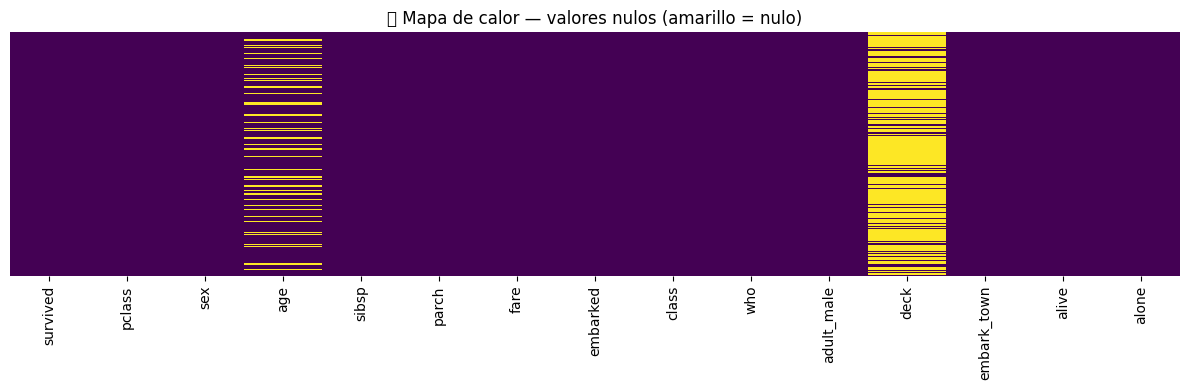

In [40]:
# ── 1.1 Cargar datos ──────────────────────────────────────────────────────────
df = sns.load_dataset("titanic")
print(f"Shape inicial: {df.shape}")
print(f"\nPrimeras filas:")
display(df.head())
# ── 1.2 Detectar nulos ────────────────────────────────────────────────────────
print("\n📊 Valores nulos por columna:")
nulos = df.isnull().sum()
porcentaje = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje %': porcentaje})
print(resumen_nulos[resumen_nulos['Nulos'] > 0])
# Mapa de calor de nulos
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("🗺️ Mapa de calor — valores nulos (amarillo = nulo)")
plt.tight_layout()
plt.show()

In [41]:
# ── 1.3 Tratamiento de nulos ──────────────────────────────────────────────────

# deck tiene ~77% nulos → eliminar la columna completa
print(f"Columna 'deck' antes: {df['deck'].notna().sum()} valores válidos de {len(df)}")
df.drop(columns=['deck'], inplace=True)

# embark_town: ~0.2% nulos → eliminar esas filas (son irrelevantes)
df.dropna(subset=['embark_town'], inplace=True)

# age: ~20% nulos → imputar con MEDIANA (hay outliers: bebés y ancianos)
mediana_age = df['age'].median()
df['age'].fillna(mediana_age, inplace=True)
print(f"Mediana edad usada para imputación: {mediana_age}")

# embarked: ~0.2% nulos → imputar con MODA (variable categórica)
moda_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(moda_embarked, inplace=True)
print(f"Moda embarked usada para imputación: '{moda_embarked}'")

# Verificar que no quedan nulos relevantes
print(f"\n✅ Nulos restantes:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nShape final: {df.shape}")


Columna 'deck' antes: 203 valores válidos de 891
Mediana edad usada para imputación: 28.0
Moda embarked usada para imputación: 'S'

✅ Nulos restantes:
Series([], dtype: int64)

Shape final: (889, 14)


In [42]:
# ── 1.4 Imputación avanzada con KNN (demostración) ───────────────────────────
# KNN imputer rellena usando los k vecinos más similares
# Útil cuando la variable tiene correlación con otras (ej: fare ~ age)
df_demo = sns.load_dataset("titanic")[['age', 'fare']].copy()
print(f"Nulos antes de KNN imputer → age: {df_demo['age'].isna().sum()}, fare: {df_demo['fare'].isna().sum()}")

knn_imputer = KNNImputer(n_neighbors=5)
df_demo[['age', 'fare']] = knn_imputer.fit_transform(df_demo[['age', 'fare']])
print(f"Nulos después de KNN imputer → age: {df_demo['age'].isna().sum()}, fare: {df_demo['fare'].isna().sum()}")
print("💡 KNN imputer usa los 5 pasajeros más similares para estimar el valor faltante")

# ── 1.5 Duplicados ────────────────────────────────────────────────────────────
duplicados = df[df.duplicated()]
print(f"\n🔍 Duplicados encontrados: {len(duplicados)}")
df.drop_duplicates(inplace=True)
print(f"Shape después de eliminar duplicados: {df.shape}")

# ── 1.6 Valores erróneos ──────────────────────────────────────────────────────
print(f"\n📈 Estadísticas de 'fare':")
print(df['fare'].describe())

# fare negativo no tiene sentido (precio de boleto no puede ser negativo)
negativos = (df['fare'] < 0).sum()
print(f"\nTarifas negativas: {negativos}")
df.loc[df['fare'] < 0, 'fare'] = df['fare'].median()

# age errónea: edad negativa o mayor a 120 años no tiene sentido
edad_erronea = ((df['age'] < 0) | (df['age'] > 120)).sum()
print(f"Edades erróneas (< 0 o > 120): {edad_erronea}")
df.loc[(df['age'] < 0) | (df['age'] > 120), 'age'] = df['age'].median()

print(f"\n✅ Limpieza completa. Shape final: {df.shape}")

Nulos antes de KNN imputer → age: 177, fare: 0
Nulos después de KNN imputer → age: 0, fare: 0
💡 KNN imputer usa los 5 pasajeros más similares para estimar el valor faltante

🔍 Duplicados encontrados: 116
Shape después de eliminar duplicados: (773, 14)

📈 Estadísticas de 'fare':
count    773.000000
mean      34.761659
std       52.425906
min        0.000000
25%        8.050000
50%       15.900000
75%       33.500000
max      512.329200
Name: fare, dtype: float64

Tarifas negativas: 0
Edades erróneas (< 0 o > 120): 0

✅ Limpieza completa. Shape final: (773, 14)


---
## 2. ⚙️ Transformación de Datos y Feature Engineering
**Dataset:** Titanic (continuación)

### ¿Por qué transformar?
- sklearn **no acepta strings** → hay que codificar categóricas
- Algoritmos basados en distancia (KNN, K-Means) **se rompen con escalas distintas**
- Variables nuevas pueden **capturar patrones** que las originales no expresan

### Transformaciones aplicadas:
1. `LabelEncoder` → sex (binario: male/female)
2. `pd.get_dummies` → embarked (categórica sin orden)
3. `StandardScaler` → age, fare
4. Feature Engineering → family_size, is_alone, is_minor

In [43]:
# ── 2.1 Codificación de variables categóricas ─────────────────────────────────

# LabelEncoder: sex tiene solo 2 valores → male=1, female=0
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
print(f"'sex' codificado: {df['sex'].unique()} (0=female, 1=male)")

# pd.get_dummies: embarked tiene 3 valores sin orden → crea columnas binarias
# drop_first=True elimina una columna para evitar multicolinealidad
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)
print(f"\nColumnas después de get_dummies: {[c for c in df.columns if 'embark' in c]}")

# Verificar estado actual
print(f"\nColumnas del DataFrame: {list(df.columns)}")
print(f"Shape: {df.shape}")


'sex' codificado: [1 0] (0=female, 1=male)

Columnas después de get_dummies: ['embark_town', 'embarked_Q', 'embarked_S']

Columnas del DataFrame: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'embarked_Q', 'embarked_S']
Shape: (773, 15)


In [44]:
# ── 2.2 Escalado de variables numéricas ──────────────────────────────────────

# StandardScaler → media=0, std=1
# Necesario para KNN y Regresión Logística
scaler = StandardScaler()
df[['age', 'fare']] = scaler.fit_transform(df[['age', 'fare']])

print("Estadísticas DESPUÉS de StandardScaler:")
print(df[['age', 'fare']].describe().round(3))
print("\n💡 Media ≈ 0 y std ≈ 1 confirman que el escalado funcionó")

# ── Demostración RobustScaler (reto del lab) ──────────────────────────────────
from sklearn.preprocessing import RobustScaler

df_demo2 = sns.load_dataset("titanic")[['age', 'fare']].dropna()
robust = RobustScaler()
demo_scaled = robust.fit_transform(df_demo2)
print(f"\n📊 RobustScaler usa mediana en lugar de media → mejor con outliers")
print(f"Mediana de fare original: {df_demo2['fare'].median():.2f}")
print(f"Mediana de fare con RobustScaler: {demo_scaled[:, 1].mean():.3f} (≈0)")

Estadísticas DESPUÉS de StandardScaler:
           age     fare
count  773.000  773.000
mean     0.000    0.000
std      1.001    1.001
min     -2.121   -0.663
25%     -0.621   -0.510
50%     -0.111   -0.360
75%      0.472   -0.024
max      3.678    9.115

💡 Media ≈ 0 y std ≈ 1 confirman que el escalado funcionó

📊 RobustScaler usa mediana en lugar de media → mejor con outliers
Mediana de fare original: 15.74
Mediana de fare con RobustScaler: 0.748 (≈0)


Distribución de family_size:
family_size
1     435
2     154
3     101
4      28
5      13
6      22
7      12
8       6
11      2
Name: count, dtype: int64

Viajaban solos: 435 (56.3%)
Menores de 18: 158 (20.4%)


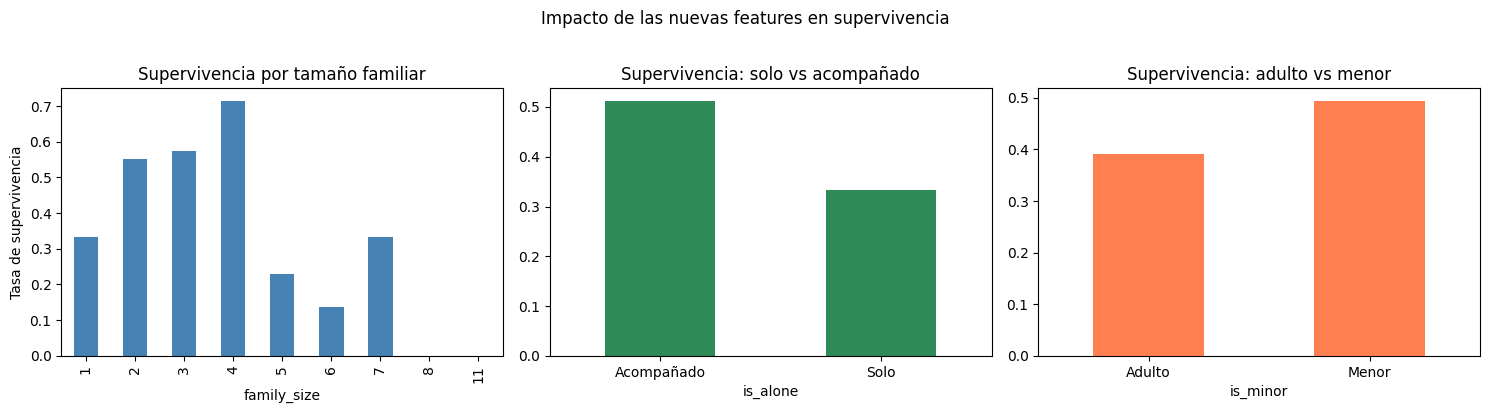


✅ Feature Engineering completo
Shape final: (773, 18)


In [45]:
# ── 2.3 Creación de nuevas características ───────────────────────────────────

# family_size: tamaño real de la familia a bordo
df['family_size'] = df['sibsp'] + df['parch'] + 1  # +1 = el pasajero mismo
print("Distribución de family_size:")
print(df['family_size'].value_counts().sort_index())

# is_alone: viaja solo (family_size == 1)
df['is_alone'] = np.where(df['family_size'] == 1, 1, 0)
print(f"\nViajaban solos: {df['is_alone'].sum()} ({df['is_alone'].mean()*100:.1f}%)")

# is_minor: menor de 18 años (reto del lab)
# IMPORTANTE: age ya está escalada, entonces is_minor se calcula
# comparando contra el valor escalado de 18
# edad original mediana ≈ 28, std ≈ 14 → (18 - 28) / 14 ≈ -0.71
umbral_menor = (18 - 28) / 14
df['is_minor'] = np.where(df['age'] < umbral_menor, 1, 0)
print(f"Menores de 18: {df['is_minor'].sum()} ({df['is_minor'].mean()*100:.1f}%)")

# Visualizar supervivencia por nueva feature
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('family_size')['survived'].mean().plot(
    kind='bar', ax=axes[0], color='steelblue', title='Supervivencia por tamaño familiar')
axes[0].set_ylabel('Tasa de supervivencia')

df.groupby('is_alone')['survived'].mean().plot(
    kind='bar', ax=axes[1], color='seagreen',
    title='Supervivencia: solo vs acompañado')
axes[1].set_xticklabels(['Acompañado', 'Solo'], rotation=0)

df.groupby('is_minor')['survived'].mean().plot(
    kind='bar', ax=axes[2], color='coral',
    title='Supervivencia: adulto vs menor')
axes[2].set_xticklabels(['Adulto', 'Menor'], rotation=0)

plt.suptitle('Impacto de las nuevas features en supervivencia', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ Feature Engineering completo")
print(f"Shape final: {df.shape}")


In [49]:
# ── 2.4 Selección de características relevantes ───────────────────────────────

# Verificar columnas disponibles tras todas las transformaciones
print("Columnas disponibles:", list(df.columns))

# Seleccionar features relevantes para el modelo
# Excluimos: who, adult_male, alive, alone (redundantes o data leakage)
feature_cols = ['sex', 'age', 'fare', 'pclass', 'family_size',
                'is_alone', 'is_minor', 'embarked_Q', 'embarked_S']

# Verificar que existen en el df
feature_cols = [c for c in feature_cols if c in df.columns]

X_titanic = df[feature_cols]
y_titanic = df['survived']

print(f"\nFeatures seleccionadas: {feature_cols}")
print(f"Shape X: {X_titanic.shape}")
print(f"Balance de clases → sobrevivió: {y_titanic.mean()*100:.1f}%")

Columnas disponibles: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone', 'embarked_Q', 'embarked_S', 'family_size', 'is_alone', 'is_minor']

Features seleccionadas: ['sex', 'age', 'fare', 'pclass', 'family_size', 'is_alone', 'is_minor', 'embarked_Q', 'embarked_S']
Shape X: (773, 9)
Balance de clases → sobrevivió: 41.1%


---
## 3. 🔄 Validación Cruzada
**Dataset:** Iris (sklearn)

### El problema del train_test_split simple:
- Una sola partición puede ser "afortunada" o "desafortunada"
- El modelo puede parecer mejor o peor de lo que realmente es

### K-Fold Cross Validation:
- Divide los datos en K partes (folds)
- Entrena K veces, cada vez usando un fold distinto como test
- El resultado final es el **promedio** → más confiable

### KFold vs StratifiedKFold:
- `KFold` → partición aleatoria
- `StratifiedKFold` → mantiene proporción de clases en cada fold (mejor para clasificación)

In [51]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
print(f"Dataset Iris → Shape: {X_iris.shape}")
print(f"Clases: {iris.target_names} → {np.bincount(y_iris)} muestras cada una")

# ── 3.2 KFold básico con Árbol de Decisión ────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
modelo_tree = DecisionTreeClassifier(random_state=42)

scores_kf = cross_val_score(modelo_tree, X_iris, y_iris,
                             cv=kf, scoring='accuracy')

print(f"\n📊 KFold Cross Validation (5 folds):")
print(f"Precisión por fold: {scores_kf.round(4)}")
print(f"Precisión media:    {scores_kf.mean():.4f}")
print(f"Desviación std:     {scores_kf.std():.4f}")
print(f"\n💡 La std baja ({scores_kf.std():.3f}) indica que el modelo es estable entre folds")


Dataset Iris → Shape: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica'] → [50 50 50] muestras cada una

📊 KFold Cross Validation (5 folds):
Precisión por fold: [1.     0.9667 0.9333 0.9333 0.9333]
Precisión media:    0.9533
Desviación std:     0.0267

💡 La std baja (0.027) indica que el modelo es estable entre folds


In [56]:
#── 3.3 StratifiedKFold ───────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_skf = cross_val_score(modelo_tree, X_iris, y_iris,
                              cv=skf, scoring='accuracy')

print(f"📊 StratifiedKFold Cross Validation (5 folds):")
print(f"Precisión por fold: {scores_skf.round(4)}")
print(f"Precisión media:    {scores_skf.mean():.4f}")
print(f"Desviación std:     {scores_skf.std():.4f}")

# ── 3.4 Reto: KNN vs Árbol con validación cruzada ────────────────────────────
modelo_knn = KNeighborsClassifier(n_neighbors=5)
scores_knn = cross_val_score(modelo_knn, X_iris, y_iris,
                              cv=skf, scoring='accuracy')

print(f"\n📊 KNN con StratifiedKFold:")
print(f"Precisión media: {scores_knn.mean():.4f} | std: {scores_knn.std():.4f}")

# ── 3.5 Reto: diferentes valores de K en KFold ───────────────────────────────
print(f"\n📊 Efecto del número de folds en la precisión (Árbol de Decisión):")
for k in [3, 5, 7, 10]:
    kf_temp = KFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(modelo_tree, X_iris, y_iris, cv=kf_temp, scoring='accuracy')
    print(f"  K={k:2d} folds → media: {s.mean():.4f} | std: {s.std():.4f}")

    # ── 3.6 Comparación final ─────────────────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"{'Método':<30} {'Media':>8} {'Std':>8}")
print(f"{'─'*45}")
print(f"{'KFold (Árbol)':<30} {scores_kf.mean():>8.4f} {scores_kf.std():>8.4f}")
print(f"{'StratifiedKFold (Árbol)':<30} {scores_skf.mean():>8.4f} {scores_skf.std():>8.4f}")
print(f"{'StratifiedKFold (KNN)':<30} {scores_knn.mean():>8.4f} {scores_knn.std():>8.4f}")
print(f"{'─'*45}")
print(f"\n✅ Validación cruzada completa")



📊 StratifiedKFold Cross Validation (5 folds):
Precisión por fold: [1.     0.9667 0.9333 0.9667 0.9   ]
Precisión media:    0.9533
Desviación std:     0.0340

📊 KNN con StratifiedKFold:
Precisión media: 0.9667 | std: 0.0298

📊 Efecto del número de folds en la precisión (Árbol de Decisión):
  K= 3 folds → media: 0.9400 | std: 0.0283
  K= 5 folds → media: 0.9533 | std: 0.0267
  K= 7 folds → media: 0.9527 | std: 0.0509
  K=10 folds → media: 0.9400 | std: 0.0554

─────────────────────────────────────────────
Método                            Media      Std
─────────────────────────────────────────────
KFold (Árbol)                    0.9533   0.0267
StratifiedKFold (Árbol)          0.9533   0.0340
StratifiedKFold (KNN)            0.9667   0.0298
─────────────────────────────────────────────

✅ Validación cruzada completa


---
## 4. 📈 Regresión Lineal
**Dataset:** California Housing (sklearn) — 20,640 viviendas

### ¿Qué predice?
El valor medio de viviendas (`MedHouseVal`) en bloques censales de California.

### Features disponibles:
| Feature | Descripción |
|---|---|
| MedInc | Ingreso medio del bloque |
| HouseAge | Antigüedad media de las casas |
| AveRooms | Promedio de habitaciones |
| AveBedrms | Promedio de dormitorios |
| Population | Población del bloque |
| AveOccup | Promedio de ocupantes por casa |
| Latitude | Latitud |
| Longitude | Longitud |

### Métricas:
- **MSE** → error cuadrático medio (menor = mejor)
- **RMSE** → raíz del MSE (mismas unidades que el target)
- **R²** → % de varianza explicada (mayor = mejor, máximo 1.0)

In [59]:
# ── 4.1 Cargar California Housing ────────────────────────────────────────────
california = fetch_california_housing()
X_cal = pd.DataFrame(california.data, columns=california.feature_names)
y_cal = pd.Series(california.target, name="MedHouseVal")

print(f"Shape: {X_cal.shape}")
print(f"\nEstadísticas del target (precio en $100,000):")
print(y_cal.describe().round(3))
# ── 4.2 División train/test ───────────────────────────────────────────────────
X_train_cal, X_test_cal, y_train_cal, y_test_cal = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42)

print(f"\nTrain: {X_train_cal.shape} | Test: {X_test_cal.shape}")

# ── 4.3 Entrenar modelo ───────────────────────────────────────────────────────
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_cal, y_train_cal)

# ── 4.4 Predicciones y métricas ──────────────────────────────────────────────
y_pred_cal = modelo_lr.predict(X_test_cal)

mse  = mean_squared_error(y_test_cal, y_pred_cal)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_cal, y_pred_cal)

print(f"\n{'─'*40}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}  (en unidades de $100,000)")
print(f"R²:   {r2:.4f}  → el modelo explica el {r2*100:.1f}% de la varianza")
print(f"{'─'*40}")
print(f"\n💡 RMSE={rmse:.2f} significa error promedio de ${rmse*100_000:,.0f} por vivienda")

Shape: (20640, 8)

Estadísticas del target (precio en $100,000):
count    20640.000
mean         2.069
std          1.154
min          0.150
25%          1.196
50%          1.797
75%          2.647
max          5.000
Name: MedHouseVal, dtype: float64

Train: (16512, 8) | Test: (4128, 8)

────────────────────────────────────────
MSE:  0.5559
RMSE: 0.7456  (en unidades de $100,000)
R²:   0.5758  → el modelo explica el 57.6% de la varianza
────────────────────────────────────────

💡 RMSE=0.75 significa error promedio de $74,558 por vivienda


📊 Coeficientes del modelo (impacto en precio):
   Feature  Coeficiente
 AveBedrms     0.783145
    MedInc     0.448675
  HouseAge     0.009724
Population    -0.000002
  AveOccup    -0.003526
  AveRooms    -0.123323
  Latitude    -0.419792
 Longitude    -0.433708

Intercepto (b): -37.0233

💡 MedInc tiene el coeficiente más alto → ingresos del vecindario
   es el mejor predictor del precio de la vivienda


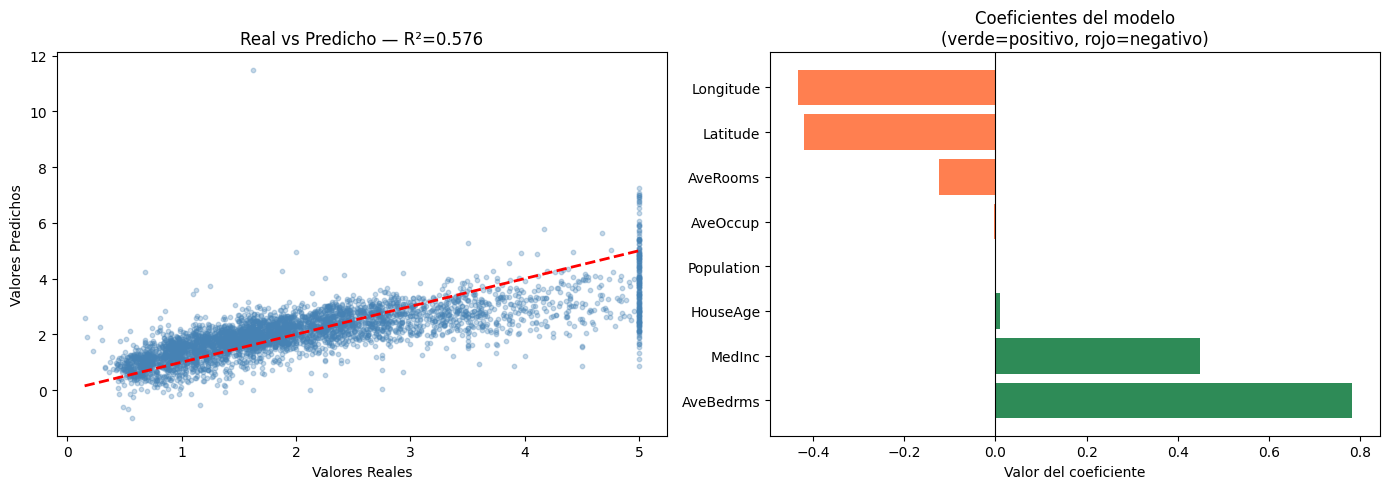


📊 R² con validación cruzada (5 folds):
Por fold: [0.5487 0.4682 0.5508 0.537  0.6605]
Media: 0.5530 | Std: 0.0617

✅ Regresión lineal completa


In [65]:
# ── 4.5 Interpretación de coeficientes ───────────────────────────────────────
coefs = pd.DataFrame({
    'Feature': california.feature_names,
    'Coeficiente': modelo_lr.coef_
}).sort_values('Coeficiente', ascending=False)

print("📊 Coeficientes del modelo (impacto en precio):")
print(coefs.to_string(index=False))
print(f"\nIntercepto (b): {modelo_lr.intercept_:.4f}")
print(f"\n💡 MedInc tiene el coeficiente más alto → ingresos del vecindario")
print(f"   es el mejor predictor del precio de la vivienda")

# ── 4.6 Visualización ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Scatter: predichos vs reales
axes[0].scatter(y_test_cal, y_pred_cal, alpha=0.3, color='steelblue', s=10)
axes[0].plot([y_cal.min(), y_cal.max()],
             [y_cal.min(), y_cal.max()], '--r', lw=2)
axes[0].set_xlabel("Valores Reales")
axes[0].set_ylabel("Valores Predichos")
axes[0].set_title(f"Real vs Predicho — R²={r2:.3f}")

# Coeficientes
colors = ['seagreen' if c > 0 else 'coral' for c in coefs['Coeficiente']]
axes[1].barh(coefs['Feature'], coefs['Coeficiente'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Coeficientes del modelo\n(verde=positivo, rojo=negativo)")
axes[1].set_xlabel("Valor del coeficiente")

plt.tight_layout()
plt.show()

# ── 4.7 Validación cruzada del modelo ────────────────────────────────────────
scores_lr = cross_val_score(modelo_lr, X_cal, y_cal,
                             cv=5, scoring='r2')
print(f"\n📊 R² con validación cruzada (5 folds):")
print(f"Por fold: {scores_lr.round(4)}")
print(f"Media: {scores_lr.mean():.4f} | Std: {scores_lr.std():.4f}")
print(f"\n✅ Regresión lineal completa")


In [66]:
# ── 4.8 Reto: normalizar antes de entrenar ───────────────────────────────────
# Sin escalar, los coeficientes NO son comparables entre features
# Con escalar, cada coeficiente refleja el impacto REAL de cada variable

scaler_cal = StandardScaler()
X_cal_scaled = scaler_cal.fit_transform(X_cal)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_cal_scaled, y_cal, test_size=0.2, random_state=42)

modelo_lr_scaled = LinearRegression()
modelo_lr_scaled.fit(X_tr_s, y_tr_s)
y_pred_scaled = modelo_lr_scaled.predict(X_te_s)

r2_scaled = r2_score(y_te_s, y_pred_scaled)
print(f"R² sin escalar:  {r2:.4f}")
print(f"R² con escalar:  {r2_scaled:.4f}")
print(f"💡 R² es idéntico — escalar NO mejora regresión lineal")
print(f"   pero SÍ hace los coeficientes comparables:\n")

coefs_scaled = pd.DataFrame({
    'Feature': california.feature_names,
    'Coeficiente': modelo_lr_scaled.coef_
}).sort_values('Coeficiente', ascending=False)

print(coefs_scaled.to_string(index=False))
print(f"\n✅ Ahora MedInc aparece como el predictor más importante")


R² sin escalar:  0.5758
R² con escalar:  0.5758
💡 R² es idéntico — escalar NO mejora regresión lineal
   pero SÍ hace los coeficientes comparables:

   Feature  Coeficiente
    MedInc     0.852382
 AveBedrms     0.371132
  HouseAge     0.122382
Population    -0.002298
  AveOccup    -0.036624
  AveRooms    -0.305116
 Longitude    -0.868927
  Latitude    -0.896635

✅ Ahora MedInc aparece como el predictor más importante


---
## 5. 🏆 Modelos de Clasificación
**Dataset:** California Housing → target binarizado (Alto/Bajo valor)

### Conversión del problema:
- Regresión → predice precio exacto (continuo)
- Clasificación → predice categoría (Alto=1 / Bajo=0)

### Modelos comparados:
| Modelo | Tipo | Ventaja |
|---|---|---|
| KNN | Instance-based | Simple, no asume distribución |
| Regresión Logística | Linear | Rápido, interpretable |
| Árbol de Decisión | Rule-based | Muy interpretable |
| Random Forest | Ensemble | Alta precisión, robusto |

In [70]:
# ── 5.1 Preparar datos de clasificación ──────────────────────────────────────
X_clf = pd.DataFrame(california.data, columns=california.feature_names)
y_clf = pd.Series(
    california.target >= california.target.mean(),
    name="HighValue"
).astype(int)

print(f"Balance de clases:")
print(f"  Alto valor (1): {y_clf.sum()} ({y_clf.mean()*100:.1f}%)")
print(f"  Bajo valor (0): {(1-y_clf).sum()} ({(1-y_clf).mean()*100:.1f}%)")

# Escalar — obligatorio para KNN y Regresión Logística
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

# División train/test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2,
    random_state=42, stratify=y_clf)  # stratify mantiene balance

print(f"\nTrain: {X_tr.shape} | Test: {X_te.shape}")

# ── 5.2 Entrenar los 4 modelos ────────────────────────────────────────────────
modelos = {
    'KNN':                  KNeighborsClassifier(n_neighbors=5),
    'Regresión Logística':  LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión':    DecisionTreeClassifier(random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42)
}

predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_tr, y_tr)
    predicciones[nombre] = modelo.predict(X_te)
    acc = accuracy_score(y_te, predicciones[nombre])
    print(f"{nombre:<25} → Accuracy: {acc:.4f}")

print(f"\n✅ 4 modelos entrenados")


Balance de clases:
  Alto valor (1): 8385 (40.6%)
  Bajo valor (0): 12255 (59.4%)

Train: (16512, 8) | Test: (4128, 8)
KNN                       → Accuracy: 0.8266
Regresión Logística       → Accuracy: 0.8292
Árbol de Decisión         → Accuracy: 0.8299
Random Forest             → Accuracy: 0.8854

✅ 4 modelos entrenados


In [72]:
# ── 5.3 Reporte completo de cada modelo ──────────────────────────────────────
for nombre, y_pred in predicciones.items():
    print(f"\n{'═'*50}")
    print(f"  {nombre}")
    print(f"{'═'*50}")
    print(classification_report(y_te, y_pred,
                                 target_names=['Bajo (0)', 'Alto (1)']))

# ── 5.4 Tabla comparativa de accuracy ────────────────────────────────────────
print(f"\n{'─'*45}")
print(f"{'Modelo':<25} {'Accuracy':>10} {'CV Mean':>10}")
print(f"{'─'*45}")

skf_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for nombre, modelo in modelos.items():
    acc = accuracy_score(y_te, predicciones[nombre])
    cv  = cross_val_score(modelo, X_clf_scaled, y_clf,
                          cv=skf_clf, scoring='accuracy').mean()
    print(f"{nombre:<25} {acc:>10.4f} {cv:>10.4f}")
print(f"{'─'*45}")
print(f"\n✅ Comparación completa")


══════════════════════════════════════════════════
  KNN
══════════════════════════════════════════════════
              precision    recall  f1-score   support

    Bajo (0)       0.84      0.87      0.86      2451
    Alto (1)       0.80      0.76      0.78      1677

    accuracy                           0.83      4128
   macro avg       0.82      0.82      0.82      4128
weighted avg       0.83      0.83      0.83      4128


══════════════════════════════════════════════════
  Regresión Logística
══════════════════════════════════════════════════
              precision    recall  f1-score   support

    Bajo (0)       0.84      0.87      0.86      2451
    Alto (1)       0.81      0.76      0.78      1677

    accuracy                           0.83      4128
   macro avg       0.82      0.82      0.82      4128
weighted avg       0.83      0.83      0.83      4128


══════════════════════════════════════════════════
  Árbol de Decisión
════════════════════════════════════════